# Parallelogram Lattice: Split-Triangle Design

This notebook uses a parallelogram unit cell split into two virtual triangles. Each triangle carries corner air holes and a center air hole, giving 8 air holes per parallelogram.

## Contents:
- **Cell 2**: Parallelogram unit cell and lattice, plus the square-transformed view of the same hole pattern
- **Cell 3**: MEEP photonic band structure simulation for the non-transformed parallelogram structure
- **Cell 4**: MEEP photonic band structure simulation for the transformed square unit cell
- **Cell 5**: Volterra-transformed square structure and Hz field plot for a quadrupole-like mode

The structure plot shows both the original parallelogram and the transformed square mapping.

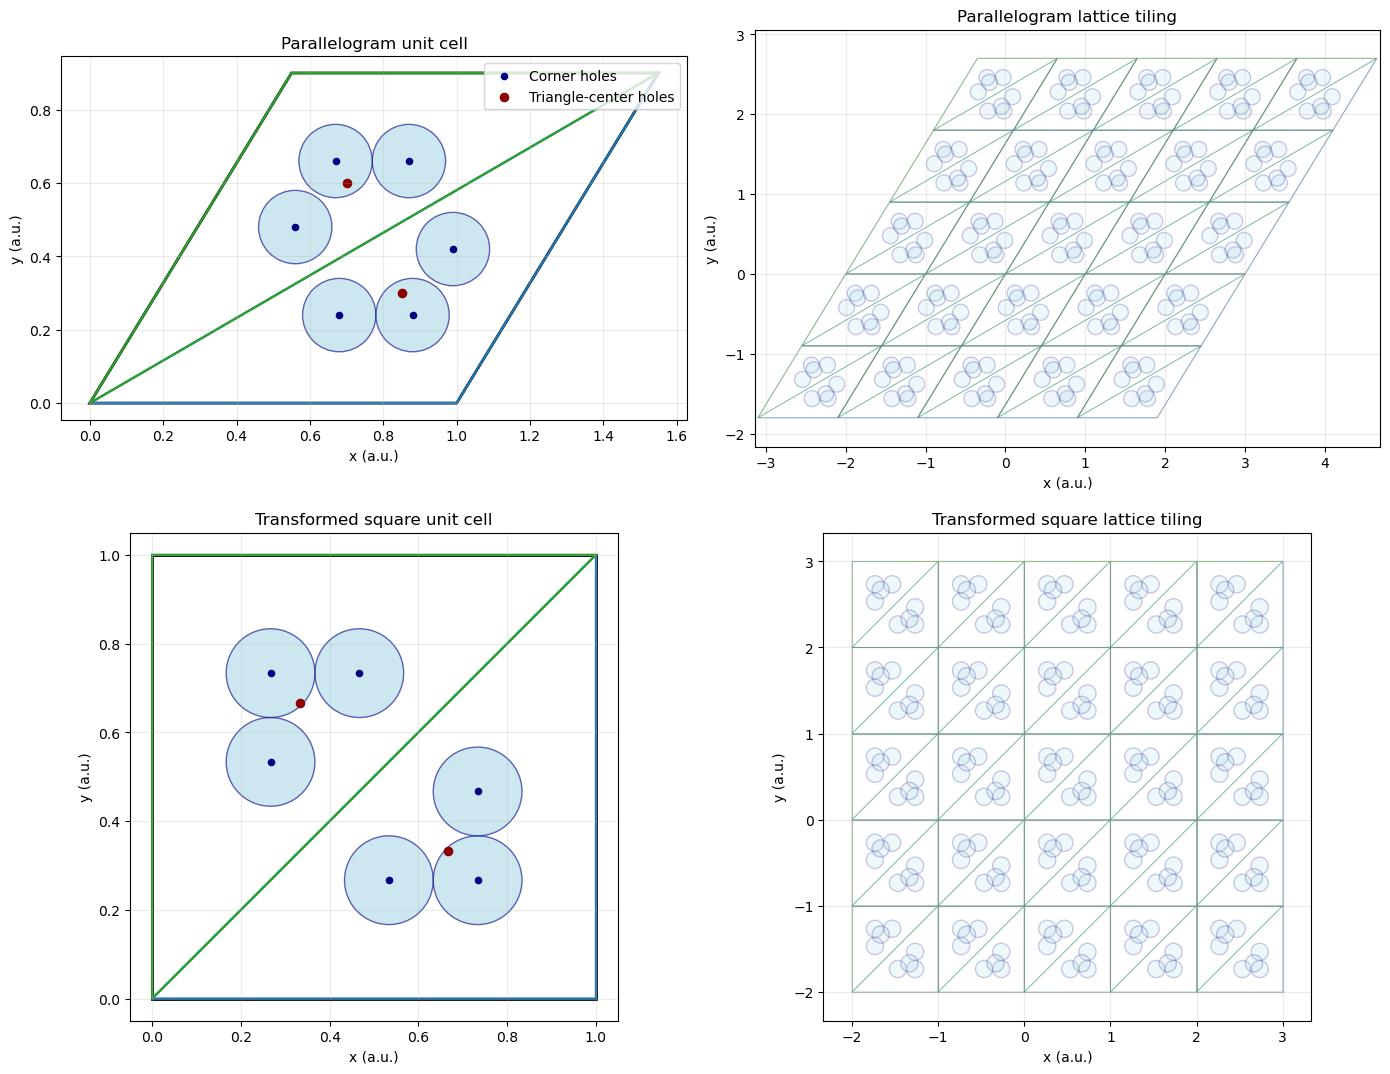

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, Circle, Rectangle

# ============================================================
# PARALLELOGRAM UNIT CELL SPLIT INTO TWO TRIANGLES
# Each triangle has three corner holes and one center hole.
# Total: 8 holes per parallelogram.
# ============================================================
a = 1.0
corner_delta = 0.8
center_barycentric = np.array([1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0])
corner_shift_frac = np.array([0.0, 0.0])
center_shift_frac = np.array([0.0, 0.0])
r_corner = 0.1 * a
r_center = 0.00 * a

# Parallelogram primitive lattice vectors
# The second basis vector makes the cell oblique.
a1 = np.array([1.0, 0.0])
a2 = np.array([0.55, 0.90])

# Square basis used for the transformed view
s1 = np.array([1.0, 0.0])
s2 = np.array([0.0, 1.0])

# Parallelogram corners in fractional coordinates
cell_frac = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])

# Two triangles formed by the diagonal from (0, 0) to (1, 1)
tri1_frac = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
])
tri2_frac = np.array([
    [0.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])


def to_cartesian(points, basis1, basis2):
    return points[:, 0, None] * basis1 + points[:, 1, None] * basis2


def triangle_holes(tri_frac, basis1, basis2, delta, center_bary, corner_shift_frac, center_shift_frac):
    tri_cart = to_cartesian(tri_frac, basis1, basis2)
    center_bary = np.asarray(center_bary, dtype=float)
    center_bary /= center_bary.sum()
    center_frac = center_bary @ tri_frac
    center_hole = to_cartesian(center_frac[None, :], basis1, basis2)[0]
    corner_shift = corner_shift_frac[0] * basis1 + corner_shift_frac[1] * basis2
    center_shift = center_shift_frac[0] * basis1 + center_shift_frac[1] * basis2
    corner_holes = tri_cart + delta * (center_hole - tri_cart) + corner_shift
    center_hole = center_hole + center_shift
    return corner_holes, center_hole, tri_cart


corner_holes_1, center_hole_1, tri1_cart = triangle_holes(tri1_frac, a1, a2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac)
corner_holes_2, center_hole_2, tri2_cart = triangle_holes(tri2_frac, a1, a2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac)

# 8 holes total: 6 corner holes + 2 triangle-center holes
hole_positions = np.vstack([
    corner_holes_1,
    center_hole_1[None, :],
    corner_holes_2,
    center_hole_2[None, :],
])

# Transformed square geometry using the same fractional coordinates
cell_square = to_cartesian(cell_frac, s1, s2)
tri1_square = to_cartesian(tri1_frac, s1, s2)
tri2_square = to_cartesian(tri2_frac, s1, s2)
corner_holes_1_sq, center_hole_1_sq, _ = triangle_holes(tri1_frac, s1, s2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac)
corner_holes_2_sq, center_hole_2_sq, _ = triangle_holes(tri2_frac, s1, s2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac)
hole_positions_square = np.vstack([
    corner_holes_1_sq,
    center_hole_1_sq[None, :],
    corner_holes_2_sq,
    center_hole_2_sq[None, :],
])

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# -----------------------------
# Plot 1: Original unit cell
# -----------------------------
ax = axes[0, 0]
ax.add_patch(Polygon(to_cartesian(cell_frac, a1, a2), closed=True, fill=False, ec='black', lw=2.0))
ax.add_patch(Polygon(tri1_cart, closed=True, fill=False, ec='tab:blue', lw=1.6))
ax.add_patch(Polygon(tri2_cart, closed=True, fill=False, ec='tab:green', lw=1.6))

for x, y in corner_holes_1:
    ax.add_patch(Circle((x, y), r_corner, fc='lightblue', ec='navy', alpha=0.6))
for x, y in corner_holes_2:
    ax.add_patch(Circle((x, y), r_corner, fc='lightblue', ec='navy', alpha=0.6))
for x, y in [center_hole_1, center_hole_2]:
    ax.add_patch(Circle((x, y), r_center, fc='salmon', ec='darkred', alpha=0.75))

ax.scatter(hole_positions[:, 0], hole_positions[:, 1], c='navy', s=20, label='Corner holes')
ax.scatter([center_hole_1[0], center_hole_2[0]], [center_hole_1[1], center_hole_2[1]],
           c='darkred', s=35, label='Triangle-center holes')
ax.set_title('Parallelogram unit cell')
ax.set_xlabel('x (a.u.)')
ax.set_ylabel('y (a.u.)')
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25)
ax.legend(loc='upper right')

# -----------------------------
# Plot 2: Original lattice tiling
# -----------------------------
ax = axes[0, 1]
N = 2
all_points = []
for i in range(-N, N + 1):
    for j in range(-N, N + 1):
        shift = i * a1 + j * a2
        cell_shift = to_cartesian(cell_frac, a1, a2) + shift
        tri1_shift = tri1_cart + shift
        tri2_shift = tri2_cart + shift
        ax.add_patch(Polygon(cell_shift, closed=True, fill=False, ec='gray', lw=0.8, alpha=0.45))
        ax.add_patch(Polygon(tri1_shift, closed=True, fill=False, ec='tab:blue', lw=0.7, alpha=0.35))
        ax.add_patch(Polygon(tri2_shift, closed=True, fill=False, ec='tab:green', lw=0.7, alpha=0.35))
        for x, y in hole_positions + shift:
            ax.add_patch(Circle((x, y), r_corner, fc='lightblue', ec='navy', alpha=0.2))
            all_points.append([x, y])
        ax.add_patch(Circle(tuple(center_hole_1 + shift), r_center, fc='salmon', ec='darkred', alpha=0.22))
        ax.add_patch(Circle(tuple(center_hole_2 + shift), r_center, fc='salmon', ec='darkred', alpha=0.22))

all_points = np.array(all_points)
ax.set_title('Parallelogram lattice tiling')
ax.set_xlabel('x (a.u.)')
ax.set_ylabel('y (a.u.)')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(all_points[:, 0].min() - 0.6, all_points[:, 0].max() + 0.6)
ax.set_ylim(all_points[:, 1].min() - 0.6, all_points[:, 1].max() + 0.6)
ax.grid(alpha=0.25)

# -----------------------------
# Plot 3: Transformed square unit cell
# -----------------------------
ax = axes[1, 0]
ax.add_patch(Polygon(cell_square, closed=True, fill=False, ec='black', lw=2.0))
ax.add_patch(Polygon(tri1_square, closed=True, fill=False, ec='tab:blue', lw=1.6))
ax.add_patch(Polygon(tri2_square, closed=True, fill=False, ec='tab:green', lw=1.6))

for x, y in corner_holes_1_sq:
    ax.add_patch(Circle((x, y), r_corner, fc='lightblue', ec='navy', alpha=0.6))
for x, y in corner_holes_2_sq:
    ax.add_patch(Circle((x, y), r_corner, fc='lightblue', ec='navy', alpha=0.6))
for x, y in [center_hole_1_sq, center_hole_2_sq]:
    ax.add_patch(Circle((x, y), r_center, fc='salmon', ec='darkred', alpha=0.75))

ax.scatter(hole_positions_square[:, 0], hole_positions_square[:, 1], c='navy', s=20)
ax.scatter([center_hole_1_sq[0], center_hole_2_sq[0]], [center_hole_1_sq[1], center_hole_2_sq[1]],
           c='darkred', s=35)
ax.set_title('Transformed square unit cell')
ax.set_xlabel('x (a.u.)')
ax.set_ylabel('y (a.u.)')
ax.set_aspect('equal', adjustable='box')
ax.grid(alpha=0.25)

# -----------------------------
# Plot 4: Transformed square lattice tiling
# -----------------------------
ax = axes[1, 1]
all_square_points = []
for i in range(-N, N + 1):
    for j in range(-N, N + 1):
        shift = i * s1 + j * s2
        cell_shift = to_cartesian(cell_frac, s1, s2) + shift
        tri1_shift = tri1_square + shift
        tri2_shift = tri2_square + shift
        ax.add_patch(Rectangle(cell_shift[0], 1.0, 1.0, fill=False, ec='gray', lw=0.8, alpha=0.45))
        ax.add_patch(Polygon(tri1_shift, closed=True, fill=False, ec='tab:blue', lw=0.7, alpha=0.35))
        ax.add_patch(Polygon(tri2_shift, closed=True, fill=False, ec='tab:green', lw=0.7, alpha=0.35))
        for x, y in hole_positions_square + shift:
            ax.add_patch(Circle((x, y), r_corner, fc='lightblue', ec='navy', alpha=0.2))
            all_square_points.append([x, y])
        ax.add_patch(Circle(tuple(center_hole_1_sq + shift), r_center, fc='salmon', ec='darkred', alpha=0.22))
        ax.add_patch(Circle(tuple(center_hole_2_sq + shift), r_center, fc='salmon', ec='darkred', alpha=0.22))

all_square_points = np.array(all_square_points)
ax.set_title('Transformed square lattice tiling')
ax.set_xlabel('x (a.u.)')
ax.set_ylabel('y (a.u.)')
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(all_square_points[:, 0].min() - 0.6, all_square_points[:, 0].max() + 0.6)
ax.set_ylim(all_square_points[:, 1].min() - 0.6, all_square_points[:, 1].max() + 0.6)
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()


Computing photonic band structure for the parallelogram structure...
Initializing eigensolver data
Computing 6 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 80 x 80 x 1.
Solving for 6 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0.52145, 0.853282, 0)
     (0, 0, 1)
Cell volume = 0.853282
Reciprocal lattice vectors (/ 2 pi):
     (1, -0.611111, 0)
     (-0, 1.17195, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0.68,0.24,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.88,0.24,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.99,0.42,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.85,0.3,0)
          radius 0, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.56,0.48,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.87,0.66,0)
          radius 0.1, height 1e+20, axis (0

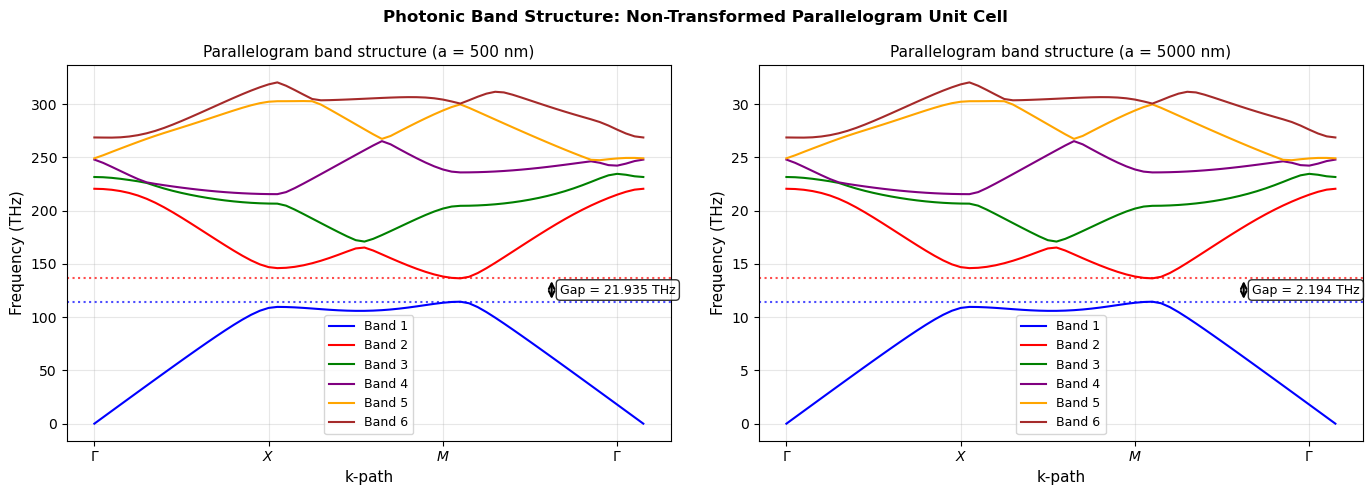

Band structure computation complete!


In [24]:
import meep as mp
from meep import mpb
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MEEP SIMULATION: NON-TRANSFORMED PARALLELOGRAM UNIT CELL
# Eight holes total: six corner holes + two triangle-center holes
# ============================================================

print('Computing photonic band structure for the parallelogram structure...')

# -------------------------------------------------
# Parameters
# -------------------------------------------------
a_values_nm = [500.0, 5000.0]
a = 1.0
corner_delta = 0.8
center_barycentric = np.array([1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0])
corner_shift_frac = np.array([0.0, 0.0])
center_shift_frac = np.array([0.0, 0.0])
r_corner = 0.1 * a
r_center = 0.00 * a
eps_bg = 3.42**2
num_bands = 6
resolution = 80

# -------------------------------------------------
# Parallelogram lattice vectors
# -------------------------------------------------
a1 = np.array([1.0, 0.0])
a2 = np.array([0.55, 0.90])

lattice = mp.Lattice(
    size=mp.Vector3(1, 1),
    basis1=mp.Vector3(a1[0], a1[1]),
    basis2=mp.Vector3(a2[0], a2[1]),
)

# k-point path for the oblique/parallelogram cell
Gamma = mp.Vector3(0, 0)
X = mp.Vector3(0.5, 0)
M = mp.Vector3(0.5, 0.5)
k_points = mp.interpolate(20, [Gamma, X, M, Gamma])

# Fractional vertices and triangle split
cell_frac = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])
tri1_frac = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
])
tri2_frac = np.array([
    [0.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])


def to_cartesian(points, basis1, basis2):
    return points[:, 0, None] * basis1 + points[:, 1, None] * basis2


def triangle_holes(tri_frac, basis1, basis2, delta, center_bary, corner_shift_frac, center_shift_frac):
    tri_cart = to_cartesian(tri_frac, basis1, basis2)
    center_bary = np.asarray(center_bary, dtype=float)
    center_bary /= center_bary.sum()
    center_frac = center_bary @ tri_frac
    center_hole = to_cartesian(center_frac[None, :], basis1, basis2)[0]
    corner_shift = corner_shift_frac[0] * basis1 + corner_shift_frac[1] * basis2
    center_shift = center_shift_frac[0] * basis1 + center_shift_frac[1] * basis2
    corner_holes = tri_cart + delta * (center_hole - tri_cart) + corner_shift
    center_hole = center_hole + center_shift
    return corner_holes, center_hole


corner_holes_1, center_hole_1 = triangle_holes(tri1_frac, a1, a2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac)
corner_holes_2, center_hole_2 = triangle_holes(tri2_frac, a1, a2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac)

# Geometry: non-transformed parallelogram structure
geometry = [
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_1[0]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_1[1]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_1[2]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_center, height=mp.inf, center=mp.Vector3(*center_hole_1), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_2[0]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_2[1]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_2[2]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_center, height=mp.inf, center=mp.Vector3(*center_hole_2), material=mp.Medium(epsilon=1.0)),
]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for idx, a_nm in enumerate(a_values_nm):
    c0 = 299_792_458.0
    freq_scale_THz = (c0 / (a_nm * 1e-9)) / 1e12

    ms = mpb.ModeSolver(
        geometry_lattice=lattice,
        geometry=geometry,
        k_points=k_points,
        resolution=resolution,
        num_bands=num_bands,
        default_material=mp.Medium(epsilon=eps_bg),
    )

    ms.run_te()

    bands = np.array(ms.all_freqs)
    bands_THz = bands * freq_scale_THz

    band1_max = bands_THz[:, 0].max()
    band2_min = bands_THz[:, 1].min()
    gap_12 = band2_min - band1_max

    ax = axs[idx]
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']
    for n in range(num_bands):
        ax.plot(bands_THz[:, n], color=colors[n], label=f'Band {n + 1}', lw=1.5)

    ax.axhline(y=band1_max, color='blue', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axhline(y=band2_min, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

    x_pos = len(bands_THz) * 0.82
    ax.annotate('', xy=(x_pos, band2_min), xytext=(x_pos, band1_max),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(x_pos + len(bands_THz) * 0.015, (band1_max + band2_min) / 2,
            f'Gap = {gap_12:.3f} THz', fontsize=9, va='center',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    xticks = [0, 20, 40, 60]
    xlabels = [r'$\Gamma$', r'$X$', r'$M$', r'$\Gamma$']
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_ylabel('Frequency (THz)', fontsize=11)
    ax.set_xlabel('k-path', fontsize=11)
    ax.set_title(f'Parallelogram band structure (a = {a_nm:.0f} nm)', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Photonic Band Structure: Non-Transformed Parallelogram Unit Cell', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Band structure computation complete!')


In [22]:
import meep as mp
from meep import mpb
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# MEEP SIMULATION: TRANSFORMED SQUARE UNIT CELL
# Same split-triangle hole pattern mapped to a square basis
# ============================================================

print('Computing photonic band structure for the transformed square structure...')

# -------------------------------------------------
# Parameters
# -------------------------------------------------
a_values_nm = [500.0, 50000.0]
a = 1.0
corner_delta = 0.6
center_barycentric = np.array([1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0])
corner_shift_frac = np.array([0.0, 0.0])
center_shift_frac = np.array([0.0, 0.0])
r_corner = 0.07 * a
r_center = 0.07 * a
eps_bg = 3.42**2
num_bands = 6
resolution = 80

# -------------------------------------------------
# Square lattice vectors
# -------------------------------------------------
s1 = np.array([1.0, 0.0])
s2 = np.array([0.0, 1.0])

lattice = mp.Lattice(
    size=mp.Vector3(1, 1),
    basis1=mp.Vector3(s1[0], s1[1]),
    basis2=mp.Vector3(s2[0], s2[1]),
)

# k-point path for the square cell
Gamma = mp.Vector3(0, 0)
X = mp.Vector3(0.5, 0)
M = mp.Vector3(0.5, 0.5)
k_points = mp.interpolate(20, [Gamma, X, M, Gamma])

# Fractional vertices and triangle split
tri1_frac = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
])
tri2_frac = np.array([
    [0.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])


def to_cartesian(points, basis1, basis2):
    return points[:, 0, None] * basis1 + points[:, 1, None] * basis2


def triangle_holes(tri_frac, basis1, basis2, delta, center_bary, corner_shift_frac, center_shift_frac):
    tri_cart = to_cartesian(tri_frac, basis1, basis2)
    center_bary = np.asarray(center_bary, dtype=float)
    center_bary /= center_bary.sum()
    center_frac = center_bary @ tri_frac
    center_hole = to_cartesian(center_frac[None, :], basis1, basis2)[0]
    corner_shift = corner_shift_frac[0] * basis1 + corner_shift_frac[1] * basis2
    center_shift = center_shift_frac[0] * basis1 + center_shift_frac[1] * basis2
    corner_holes = tri_cart + delta * (center_hole - tri_cart) + corner_shift
    center_hole = center_hole + center_shift
    return corner_holes, center_hole


corner_holes_1, center_hole_1 = triangle_holes(
    tri1_frac, s1, s2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac
)
corner_holes_2, center_hole_2 = triangle_holes(
    tri2_frac, s1, s2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac
)

# Geometry: transformed square structure
geometry = [
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_1[0]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_1[1]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_1[2]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_center, height=mp.inf, center=mp.Vector3(*center_hole_1), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_2[0]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_2[1]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_corner, height=mp.inf, center=mp.Vector3(*corner_holes_2[2]), material=mp.Medium(epsilon=1.0)),
    mp.Cylinder(radius=r_center, height=mp.inf, center=mp.Vector3(*center_hole_2), material=mp.Medium(epsilon=1.0)),
]

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for idx, a_nm in enumerate(a_values_nm):
    c0 = 299_792_458.0
    freq_scale_THz = (c0 / (a_nm * 1e-9)) / 1e12

    ms = mpb.ModeSolver(
        geometry_lattice=lattice,
        geometry=geometry,
        k_points=k_points,
        resolution=resolution,
        num_bands=num_bands,
        default_material=mp.Medium(epsilon=eps_bg),
    )

    ms.run_te()

    bands = np.array(ms.all_freqs)
    bands_THz = bands * freq_scale_THz

    band1_max = bands_THz[:, 0].max()
    band2_min = bands_THz[:, 1].min()
    gap_12 = band2_min - band1_max

    ax = axs[idx]
    colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']
    for n in range(num_bands):
        ax.plot(bands_THz[:, n], color=colors[n], label=f'Band {n + 1}', lw=1.5)

    ax.axhline(y=band1_max, color='blue', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.axhline(y=band2_min, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

    x_pos = len(bands_THz) * 0.82
    ax.annotate('', xy=(x_pos, band2_min), xytext=(x_pos, band1_max),
                arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax.text(x_pos + len(bands_THz) * 0.015, (band1_max + band2_min) / 2,
            f'Gap = {gap_12:.3f} THz', fontsize=9, va='center',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    xticks = [0, 20, 40, 60]
    xlabels = [r'$\\Gamma$', r'$X$', r'$M$', r'$\\Gamma$']
    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels)
    ax.set_ylabel('Frequency (THz)', fontsize=11)
    ax.set_xlabel('k-path', fontsize=11)
    ax.set_title(f'Transformed square band structure (a = {a_nm:.0f} nm)', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Photonic Band Structure: Transformed Square Unit Cell', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Transformed square band structure computation complete!')


Computing photonic band structure for the transformed square structure...
Initializing eigensolver data
Computing 6 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 80 x 80 x 1.
Solving for 6 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (1, 0, 0)
     (0, 1, 0)
     (0, 0, 1)
Cell volume = 1
Reciprocal lattice vectors (/ 2 pi):
     (1, -0, 0)
     (-0, 1, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0.4,0.2,0)
          radius 0.07, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.8,0.2,0)
          radius 0.07, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.8,0.6,0)
          radius 0.07, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.666667,0.333333,0)
          radius 0.07, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.2,0.4,0)
          radius 0.07, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.6,0.8,0)
          radius 0.07, height 1e+20, axis (0, 0, 1)
     cylinder

ValueError: 
$\\Gamma$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

Error in callback <function _draw_all_if_interactive at 0x7fe42cb44cc0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
$\\Gamma$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

ValueError: 
$\\Gamma$
^
ParseException: Expected end of text, found '$'  (at char 0), (line:1, col:1)

<Figure size 1400x500 with 2 Axes>

In [28]:
import meep as mp
from meep import mpb
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# ============================================================
# C4 -> C5 VOLTERRA SYMMETRY TRANSFORM ON A SUPERCELL LATTICE
# HZ field plot over lattice sites (not just one unit cell)
# ============================================================

print('Running C4->C5 Volterra process on lattice and plotting Hz field...')

# -------------------------------------------------
# Parameters
# -------------------------------------------------
a = 1.0
corner_delta = 0.8
center_barycentric = np.array([1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0])
corner_shift_frac = np.array([0.0, 0.0])
center_shift_frac = np.array([0.0, 0.0])
r_corner = 0.1 * a
r_center = 0.00 * a
eps_bg = 3.42**2

# MPB controls
resolution = 48
num_bands = 16
target_band = 6

# Lattice-size control
supercell_N = 7

# Volterra controls
volterra_core = np.array([supercell_N / 2.0, supercell_N / 2.0])
volterra_strength = 1.0
burgers_vector = np.array([0.0, 0.0])

# -------------------------------------------------
# Base geometry
# -------------------------------------------------
tri1_frac = np.array([
    [0.0, 0.0],
    [1.0, 0.0],
    [1.0, 1.0],
])
tri2_frac = np.array([
    [0.0, 0.0],
    [1.0, 1.0],
    [0.0, 1.0],
])


def to_cartesian(points, basis1, basis2):
    return points[:, 0, None] * basis1 + points[:, 1, None] * basis2


def triangle_holes(tri_frac, basis1, basis2, delta, center_bary, corner_shift_frac, center_shift_frac):
    tri_cart = to_cartesian(tri_frac, basis1, basis2)
    center_bary = np.asarray(center_bary, dtype=float)
    center_bary /= center_bary.sum()
    center_frac = center_bary @ tri_frac
    center_hole = to_cartesian(center_frac[None, :], basis1, basis2)[0]
    corner_shift = corner_shift_frac[0] * basis1 + corner_shift_frac[1] * basis2
    center_shift = center_shift_frac[0] * basis1 + center_shift_frac[1] * basis2
    corner_holes = tri_cart + delta * (center_hole - tri_cart) + corner_shift
    center_hole = center_hole + center_shift
    return corner_holes, center_hole


# ============================================================
# ✅ FIXED VOLTERRA PROCESS (ONLY CHANGE)
# ============================================================
def c4_to_c5_volterra(points, core, strength=1.0, burgers=np.array([0.0, 0.0])):
    rel = points - core
    r = np.linalg.norm(rel, axis=1)
    theta = np.arctan2(rel[:, 1], rel[:, 0])

    # Frank angle for C4 -> C5
    Omega = strength * (np.pi / 2.0)

    # branch cut (critical!)
    theta_cut = 0.0

    # CORRECT Volterra mapping (piecewise, NOT scaling)
    theta_new = np.where(theta >= theta_cut, theta + Omega, theta)

    transformed = core + np.column_stack([
        r * np.cos(theta_new),
        r * np.sin(theta_new)
    ])

    # optional Burgers vector
    transformed += (strength * theta[:, None] / (2.0 * np.pi)) * burgers[None, :]

    return transformed
# ============================================================


s1 = np.array([1.0, 0.0])
s2 = np.array([0.0, 1.0])

corner_holes_1, center_hole_1 = triangle_holes(
    tri1_frac, s1, s2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac
)
corner_holes_2, center_hole_2 = triangle_holes(
    tri2_frac, s1, s2, corner_delta, center_barycentric, corner_shift_frac, center_shift_frac
)

base_corner = np.vstack([corner_holes_1, corner_holes_2])
base_center = np.vstack([center_hole_1, center_hole_2])

# -------------------------------------------------
# Build lattice
# -------------------------------------------------
corner_sites = []
center_sites = []

for i in range(supercell_N):
    for j in range(supercell_N):
        shift = np.array([i, j])
        corner_sites.append(base_corner + shift)
        center_sites.append(base_center + shift)

corner_sites = np.vstack(corner_sites)
center_sites = np.vstack(center_sites)

# Apply Volterra
corner_sites_v = c4_to_c5_volterra(
    corner_sites, volterra_core, strength=volterra_strength, burgers=burgers_vector
) % supercell_N

center_sites_v = c4_to_c5_volterra(
    center_sites, volterra_core, strength=volterra_strength, burgers=burgers_vector
) % supercell_N

# -------------------------------------------------
# MPB simulation
# -------------------------------------------------
lattice = mp.Lattice(
    size=mp.Vector3(supercell_N, supercell_N),
    basis1=mp.Vector3(1, 0),
    basis2=mp.Vector3(0, 1),
)

geometry = []

for p in corner_sites_v:
    geometry.append(
        mp.Cylinder(radius=r_corner, height=mp.inf,
                    center=mp.Vector3(*p),
                    material=mp.Medium(epsilon=1.0))
    )

for p in center_sites_v:
    if r_center > 0:
        geometry.append(
            mp.Cylinder(radius=r_center, height=mp.inf,
                        center=mp.Vector3(*p),
                        material=mp.Medium(epsilon=1.0))
        )

ms = mpb.ModeSolver(
    geometry_lattice=lattice,
    geometry=geometry,
    k_points=[mp.Vector3(0, 0)],
    resolution=resolution,
    num_bands=num_bands,
    default_material=mp.Medium(epsilon=eps_bg),
)

ms.run_te()

if target_band < 1 or target_band > num_bands:
    raise ValueError("Invalid band index")

hz = ms.get_efield(target_band)
hz = np.real(hz[:, :, 2])

plt.imshow(hz.T, origin='lower', cmap='RdBu')
plt.colorbar(label='Hz')
plt.title(f'Hz field (band {target_band})')
plt.show()

Running C4->C5 Volterra process on lattice and plotting Hz field...
Initializing eigensolver data
Computing 16 bands with 1e-07 tolerance
Working in 2 dimensions.
Grid size is 336 x 336 x 1.
Solving for 8 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (7, 0, 0)
     (0, 7, 0)
     (0, 0, 1)
Cell volume = 49
Reciprocal lattice vectors (/ 2 pi):
     (0.142857, -0, 0)
     (-0, 0.142857, -0)
     (0, -0, 1)
Geometric objects:
     cylinder, center = (0.533333,0.266667,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.733333,0.266667,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.733333,0.466667,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.266667,0.533333,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.466667,0.733333,0)
          radius 0.1, height 1e+20, axis (0, 0, 1)
     cylinder, center = (0.266667,0.733333,0)
        

IndexError: index 2 is out of bounds for axis 2 with size 1